In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ace_tools_open as tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import ace_tools_open as tools
import plotly
from neuralprophet import NeuralProphet
import torch
from neuralprophet.configure import ConfigSeasonality
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.metrics import mean_squared_error
from itertools import product
import joblib


In [2]:
# File paths for all uploaded stock data
file_paths = {
    # Consumer Goods Sector
    "CPIN": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Consumer Goods/CPIN.JK_dataprice.xlsx",
    "ICBP": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Consumer Goods/ICBP.JK_dataprice.xlsx",
    "INDF": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Consumer Goods/INDF.JK_dataprice.xlsx",
    "UNVR": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Consumer Goods/UNVR.JK_dataprice.xlsx",
    
    # Energy and Utilities Sector
    "ADRO": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Energy and Utils/ADRO.JK_dataprice.xlsx",
    "PGAS": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Energy and Utils/PGAS.JK_dataprice.xlsx",
    "PTBA": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Energy and Utils/PTBA.JK_dataprice.xlsx",

    # Finance Sector
    "BBCA": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx",
    "BBNI": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBNI.JK_dataprice.xlsx",
    "BBTN": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBTN.JK_dataprice.xlsx",
    "BMRI": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBTN.JK_dataprice.xlsx",
    "BBRI": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBRI.JK_dataprice.xlsx",
    
    # Healthcare Sector
    "KLBF": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Healthcare/KLBF.JK_dataprice.xlsx",
    "MIKA": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Healthcare/MIKA.JK_dataprice.xlsx",
    
    
    # Mines and Basic Materials Sector
    "ANTM": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/ANTM.JK_dataprice.xlsx",
    "BRPT": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/BRPT.JK_dataprice.xlsx",
    "INCO": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/INCO.JK_dataprice.xlsx",
    "INKP": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/INKP.JK_dataprice.xlsx",
    "MDKA": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/MDKA.JK_dataprice.xlsx",
    "SMGR": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/SMGR.JK_dataprice.xlsx",
    "TINS": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/TINS.JK_dataprice.xlsx",
    "UNTR": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/UNTR.JK_dataprice.xlsx",

    # Otomotive and Industrial Sector
    "ASII": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Otomotive and Industrials/ASII.JK_dataprice.xlsx",

    # Tech Sector
    "BUKA": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Tech/BUKA.JK_dataprice.xlsx",
    "EMTK": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Tech/EMTK.JK_dataprice.xlsx",
    "GOTO": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Tech/GOTO.JK_dataprice.xlsx",

    # Telecommunication Sector
    "EXCL": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Telecommunications/EXCL.JK_dataprice.xlsx",
    "TBIG": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Telecommunications/TBIG.JK_dataprice.xlsx",
    "TLKM": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Telecommunications/TLKM.JK_dataprice.xlsx",
    "TOWR": "CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Telecommunications/TOWR.JK_dataprice.xlsx",
}


In [3]:
# Dictionary to store stock data
stock_data = {}

# Load each file into a dictionary
for stock, path in file_paths.items():
    try:
        if path.endswith('.csv'):
            df = pd.read_csv(path, index_col="Date", parse_dates=True)
        elif path.endswith('.xlsx'):
            df = pd.read_excel(path, index_col="Date", parse_dates=True)
        else:
            print(f"Unsupported file format for {stock}: {path}")
            continue
        stock_data[stock] = df
    except Exception as e:
        print(f"Error loading {stock} from {path}: {e}")

# Print the first few rows of each DataFrame to debug
for stock, df in stock_data.items():
    print(f"Data for {stock}:")
    print(df.head())

# Combine all data into a single DataFrame using the "Close" column
merged_df = pd.DataFrame()
print("Columns:", df.columns.tolist())
print("Data preview:")

for stock, df in stock_data.items():
    if "Close" in df.columns:
        merged_df[stock] = df["Close"]
    else:
        print(f"Warning: 'Close' column not found in {stock}")

# Drop rows with missing values
merged_df.dropna(inplace=True)

# Display merged stock data
tools.display_dataframe_to_user(name="Merged Stock Data", dataframe=merged_df)

Data for CPIN:
                   Open         High  ...  Dividends  Stock Splits
Date                                  ...                         
2017-07-31  2530.030696  2575.699120  ...          0             0
2017-08-01  2466.094728  2575.698938  ...          0             0
2017-08-02  2530.030518  2575.698938  ...          0             0
2017-08-03  2530.030518  2548.297886  ...          0             0
2017-08-04  2484.362266  2593.966484  ...          0             0

[5 rows x 7 columns]
Data for ICBP:
                   Open         High  ...  Dividends  Stock Splits
Date                                  ...                         
2017-07-31  7590.259146  7635.171922  ...          0             0
2017-08-01  7455.520663  7500.433438  ...          0             0
2017-08-02  7455.520996  7500.433773  ...          0             0
2017-08-03  7410.608219  7477.977385  ...          0             0
2017-08-04  7410.608219  7500.433773  ...          0             0

[5 rows x

In [5]:
# === Clean NeuralProphet Forecast with Plotly ===
# Load and prepare the data
df = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx", sheet_name="Sheet1")
df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Confirm data is clean
assert df['y'].apply(lambda x: isinstance(x, (int, float))).all()

# Create and train the model without checkpointing (fixes PyTorch 2.6 error)
model = NeuralProphet(n_lags=5, n_forecasts=5, epochs=100)
model.fit(df, freq='D', minimal=True, checkpointing=False, continue_training=False)

# Forecast
future = model.make_future_dataframe(df, periods=10, n_historic_predictions=True)
forecast = model.predict(future)
forecast.to_csv("neuralprophet_forecast2.csv", index=False)

pio.renderers.default = "browser" 

# Plot using Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['y'], mode='lines', name='Actual'))
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat1'], mode='lines', name='Forecast (t+1)'))

fig.update_layout(
    title='NeuralProphet Forecast vs Actual',
    xaxis_title='Date',
    yaxis_title='Price',
    template='plotly_dark'
)

fig.show()

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.371% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\

Finding best initial lr:   0%|          | 0/232 [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\core\module.py:512: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\core\module.py:512: You called `self.log('reg_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B

In [6]:
# Load original stock data
df = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx", sheet_name="Sheet1")
forecast_df = pd.read_csv("neuralprophet_forecast.csv")

# Prepare original data
df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Calculate indicators
df['SMA_10'] = df['y'].rolling(window=10).mean()
delta = df['y'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Prepare forecast data
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
merged = pd.merge(forecast_df, df[['ds', 'SMA_10', 'RSI_14']], on='ds', how='left')

# Plot using browser
pio.renderers.default = "browser"

fig = go.Figure()
fig.add_trace(go.Scatter(x=merged['ds'], y=merged['y'], mode='lines', name='Actual'))
fig.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat1'], mode='lines', name='Forecast (t+1)'))
fig.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat2'], mode='lines', name='Forecast (t+2)'))
fig.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat3'], mode='lines', name='Forecast (t+3)'))
fig.add_trace(go.Scatter(x=merged['ds'], y=merged['SMA_10'], mode='lines', name='SMA 10', line=dict(dash='dot')))
fig.add_trace(go.Scatter(x=merged['ds'], y=merged['RSI_14'], mode='lines', name='RSI 14', yaxis='y2'))

fig.update_layout(
    title='NeuralProphet Forecast vs Actual with SMA and RSI',
    xaxis_title='Date',
    yaxis=dict(title='Price'),
    yaxis2=dict(title='RSI', overlaying='y', side='right', range=[0, 100]),
    template='plotly_dark'
)

fig.show()

In [6]:
# Check the number of rows in the dataframe
print(f"Training data length: {len(df)}")



Training data length: 1255


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.405% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\

Training: lags=1, forecasts=1, lr=1.001, seasonality=additive, epochs=100


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 13. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.405% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use 

Training: lags=1, forecasts=1, lr=1.001, seasonality=multiplicative, epochs=100


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.405% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be re

...

Failed: Input contains NaN.
Training: lags=5, forecasts=5, lr=0.2, seasonality=additive, epochs=100


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.405% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be re

Failed: Input contains NaN.
Training: lags=5, forecasts=5, lr=0.2, seasonality=multiplicative, epochs=100


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.405% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be re

Failed: Input contains NaN.
NeuralProphet Tuning Results


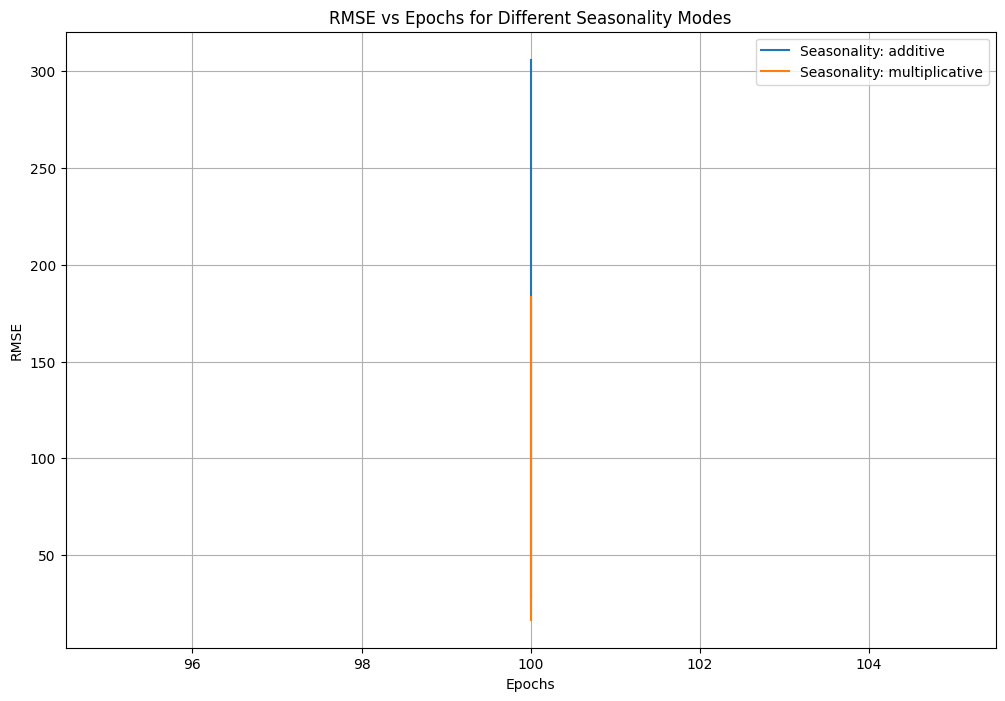

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.371% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\

Training: |          | 0/? [00:00<?, ?it/s]

ValueError: Expected positive integer total_steps, but got 5700

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from itertools import product
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet
import joblib
import ace_tools_open as tools  # Updated import for displaying results

# Load and prepare data
df = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx", sheet_name="Sheet1")
df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()  # Drop NaN values to ensure clean data

# Split data into training and validation
split_idx = int(len(df) * 0.7)
df_train = df[:split_idx]
df_val = df.iloc[split_idx:]

# Hyperparameter grid
lags_options = [1, 2, 3, 4, 5]
forecast_options = [1, 2, 3, 4, 5]
lr_options = [1.001, 0.01, 0.1, 0.2]
seasonality_options = ['additive', 'multiplicative']
fixed_epochs = 100  # Fixed epochs value

results = []

# Grid search over all combinations
for lags, n_forecasts, lr, season_mode in product(lags_options, forecast_options, lr_options, seasonality_options):
    try:
        print(f"Training: lags={lags}, forecasts={n_forecasts}, lr={lr}, seasonality={season_mode}, epochs={fixed_epochs}")
        
        # Initialize the NeuralProphet model
        model = NeuralProphet(
            n_lags=lags,
            n_forecasts=n_forecasts,
            learning_rate=lr,
            seasonality_mode=season_mode,
            epochs=fixed_epochs,
            batch_size=32  # Explicitly set batch size
        )
        
        # Add custom seasonality (quarterly)
        model.add_seasonality(name='quarterly', period=91.31, fourier_order=5)
        
        # Fit the model on the training data (removed logger argument)
        model.fit(df_train, freq='D', minimal=True, checkpointing=False, validation_df=None)

        # Create future dataframe and make predictions
        future = model.make_future_dataframe(df_train, periods=len(df_val), n_historic_predictions=False)
        forecast = model.predict(future)

        forecast = forecast[['ds', 'yhat1']].rename(columns={'yhat1': 'yhat'})
        merged = pd.merge(df_val, forecast, on='ds', how='inner')

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

        # Append the results for each model configuration
        results.append({
            'n_lags': lags,
            'n_forecasts': n_forecasts,
            'learning_rate': lr,
            'seasonality_mode': season_mode,
            'epochs': fixed_epochs,
            'RMSE': rmse
        })
    except Exception as e:
        print(f"Failed: {e}")

# Check if results contain valid data before proceeding
if results:
    # Convert results to DataFrame and sort by RMSE
    df_results = pd.DataFrame(results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
    
    # Display the top 10 results to the user
    tools.display_dataframe_to_user(name="NeuralProphet Tuning Results", dataframe=df_results.head(10))

    # Plot RMSE for all combinations
    plt.figure(figsize=(12, 8))
    for season_mode in seasonality_options:
        season_mode_results = df_results[df_results['seasonality_mode'] == season_mode]
        plt.plot(season_mode_results['epochs'], season_mode_results['RMSE'], label=f"Seasonality: {season_mode}")
    plt.title("RMSE vs Epochs for Different Seasonality Modes")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save the results to csv
    df_results.to_csv("NeuralProphet_hyperparameter_tuning_results.csv", index=False)

    # Automatically save the best model based on lowest RMSE
    best_model_config = df_results.iloc[0]
    best_model = NeuralProphet(
        n_lags=best_model_config['n_lags'],
        n_forecasts=best_model_config['n_forecasts'],
        learning_rate=best_model_config['learning_rate'],
        seasonality_mode=best_model_config['seasonality_mode'],
        epochs=best_model_config['epochs'],
        batch_size=32  # Use the same batch size
    )

    best_model.add_seasonality(name='quarterly', period=91.31, fourier_order=5)
    best_model.fit(df, freq='D', validation_df=None)

    # Save the trained model
    joblib.dump(best_model, "best_neuralprophet_model.pkl")

    print("Best model saved and results exported.")
else:
    print("No valid results to display.")


In [11]:
from sklearn.metrics import mean_squared_error
import plotly.io as pio
import plotly.graph_objects as go


# Load and prepare the data
df = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx", sheet_name="Sheet1")
df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Confirm data is clean
assert df['y'].apply(lambda x: isinstance(x, (int, float))).all()

# Final training on best configuration
print("\nTraining final model on full dataset with best hyperparameters...")
final_model = NeuralProphet(
    n_lags=1,
    n_forecasts=1,
    learning_rate=0.01,
    seasonality_mode='additive',
    epochs=100
)
final_model.add_seasonality(name='quarterly', period=91.31, fourier_order=5)
final_model.fit(df, freq='D')

# Make future forecast
future = final_model.make_future_dataframe(df, periods=10, n_historic_predictions=True)
forecast = final_model.predict(future)

# Plot final forecast
pio.renderers.default = "browser"
fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['y'], mode='lines', name='Actual'))
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat1'], mode='lines', name='Forecast'))
fig.update_layout(title="Final Forecast (Best Model)", xaxis_title="Date", yaxis_title="Price", template="plotly_dark")
fig.show()

# Evaluate final forecast
# Only compare points where both y and yhat1 are available
eval_df = forecast.dropna(subset=['y', 'yhat1'])

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat1']))
print(f"Final Forecast RMSE: {rmse:.4f}")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.371% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a futu


Training final model on full dataset with best hyperparameters...


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.371% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined freque

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


Final Forecast RMSE: 128.0384


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import plotly.io as pio
import plotly.graph_objects as go


# Load and prepare the data
df = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Mines and Basic Materials/ANTM.JK_dataprice.xlsx", sheet_name="Sheet1")
df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Confirm data is clean
assert df['y'].apply(lambda x: isinstance(x, (int, float))).all()

# Final training on best configuration
print("\nTraining final model on full dataset with best hyperparameters...")
final_model = NeuralProphet(
    n_lags=1,
    n_forecasts=1,
    learning_rate=0.01,
    seasonality_mode='additive',
    epochs=100
)
final_model.add_seasonality(name='quarterly', period=91.31, fourier_order=5)
final_model.fit(df, freq='D')

# Make future forecast
future = final_model.make_future_dataframe(df, periods=10, n_historic_predictions=True)
forecast = final_model.predict(future)

# Plot final forecast
pio.renderers.default = "browser"
fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['y'], mode='lines', name='Actual'))
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat1'], mode='lines', name='Forecast'))
fig.update_layout(title="Final Forecast (Best Model)", xaxis_title="Date", yaxis_title="Price", template="plotly_dark")
fig.show()



# Evaluate final forecast
# Only compare points where both y and yhat1 are available
eval_df = forecast.dropna(subset=['y', 'yhat1'])

#calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat1']))
mae = mean_absolute_error(eval_df['y'], eval_df['yhat1'])

print(f"\nRoot Mean Square Error (RMSE) for BBCA with NeuralProphet: {rmse:.4f}")
print(f"Mean Absolute Error (MAE) for BBCA with NeuralProphet: {mae:.4f}\n")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.289% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a futu


Training final model on full dataset with best hyperparameters...


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.289% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined freque

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column



Root Mean Square Error (RMSE) for BBCA with NeuralProphet: 38.4225
Mean Absolute Error (MAE) for BBCA with NeuralProphet: 20.4866



In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Final model with best hyperparameters
best_model = NeuralProphet(
    n_lags=1,
    n_forecasts=1,
    learning_rate=0.01,
    seasonality_mode='additive',
    epochs=100
)
best_model.add_seasonality(name='quarterly', period=91.31, fourier_order=5)
best_model.fit(df, freq='D')

# Make future forecast
future = best_model.make_future_dataframe(df, periods=10, n_historic_predictions=True)
forecast = best_model.predict(future)

# Plot final forecast
pio.renderers.default = "browser"  # Set default renderer to open in the browser
fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['y'], mode='lines', name='Actual'))
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat1'], mode='lines', name='Forecast'))
fig.update_layout(title="Final Forecast (Best Model)", xaxis_title="Date", yaxis_title="Price", template="plotly_white")
fig.show()

# Calculate RMSE for final forecast
eval_df = forecast.dropna(subset=['y', 'yhat1'])
#rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat1']))
#print(f"Final Forecast RMSE: {rmse:.4f}")
# Calculate and print RMSE and MAE
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat1']))
mae = mean_absolute_error(eval_df['y'], eval_df['yhat1'])

print(f"\nRoot Mean Square Error (RMSE) for ANTM with NeuralProphet: {rmse:.4f}")
print(f"Mean Absolute Error (MAE) for ANTM with NeuralProphet: {mae:.4f}\n")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.289% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a futu

Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.289% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined freque

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column



Root Mean Square Error (RMSE) for ANTM with NeuralProphet: 38.3798
Mean Absolute Error (MAE) for ANTM with NeuralProphet: 20.5537

